THUC HANH ANN MODEL

In [4]:
#install required libraties
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
# KerasClassifier has moved to scikeras.wrappers
# If you haven't installed scikeras, you can do so by running: !pip install scikeras
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [3]:
!pip install scikeras

In [5]:
#download mnist fashion dataset
fasion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fasion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [6]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


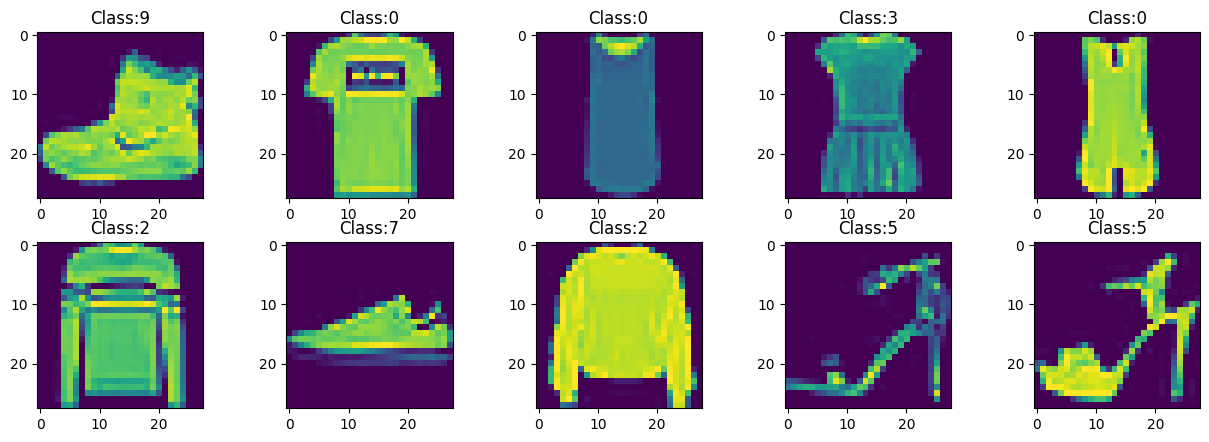

In [7]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [9]:
#initial ANN model
fasion_model = Sequential()

#add first hidden layer
fasion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fasion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fasion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fasion_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#train ANN model
model_fit = fasion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8222 - loss: 0.5045 - val_accuracy: 0.8585 - val_loss: 0.4006
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8650 - loss: 0.3713 - val_accuracy: 0.8697 - val_loss: 0.3647
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8785 - loss: 0.3327 - val_accuracy: 0.8683 - val_loss: 0.3641
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8861 - loss: 0.3088 - val_accuracy: 0.8785 - val_loss: 0.3473
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8935 - loss: 0.2882 - val_accuracy: 0.8703 - val_loss: 0.3502
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8988 - loss: 0.2720 - val_accuracy: 0.8788 - val_loss: 0.3403
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9038 - loss: 0.2596 - val_accuracy: 0.8828 - val_loss: 0.3262
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9068 - loss: 0

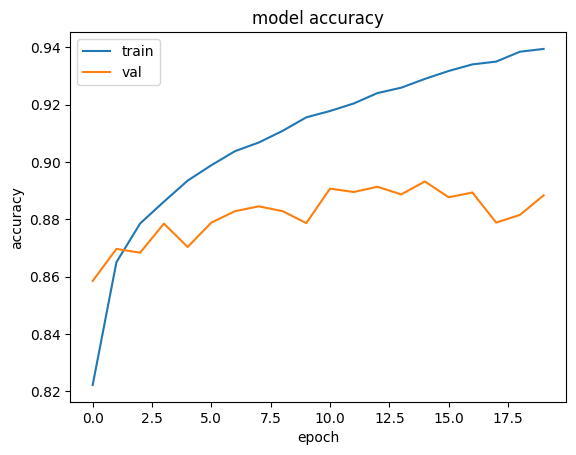

In [12]:
#Danh gia ANN model accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

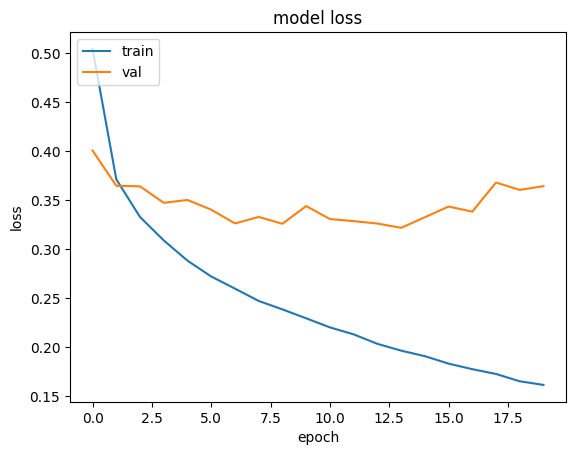

In [13]:
#Danh gia ANN model loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [14]:
#du bao anh moi
print(np.argmax(fasion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fasion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [16]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)


In [17]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)
y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [18]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense


In [20]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose = 1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8756 - loss: 1.1798
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9366 - loss: 0.2324
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9483 - loss: 0.1908
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9504 - loss: 0.2009
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9418 - loss: 0.2620
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9582 - loss: 0.1762
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9565 - loss: 0.2033
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9574 - loss: 0.2017
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9607 - loss: 0.1847
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9639 - loss: 0.1793
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9686 - loss: 0.1759
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [22]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2 2


In [27]:
img_size = (28,28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 7.6602511e-08 0.0000000e+00
  3.4830864e-19 0.0000000e+00 0.0000000e+00 9.9999988e-01 0.0000000e+00]]
8


REGRESSTION


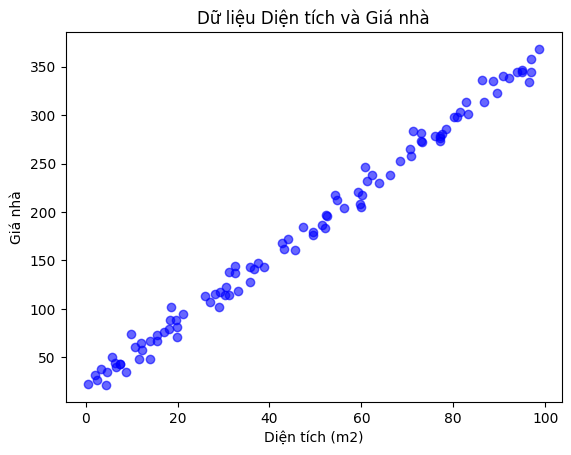

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense

# Tạo dữ liệu giả lập: 100 căn nhà
np.random.seed(42)
X_train = np.random.rand(100, 1) * 100  # Diện tích từ 0 đến 100 m2
# Công thức giả lập: Giá = 3.5 * Diện tích + 15 + Nhiễu ngẫu nhiên
y_train = 3.5 * X_train + 15 + np.random.randn(100, 1) * 10

# Trực quan hóa dữ liệu ban đầu
plt.scatter(X_train, y_train, color='blue', alpha=0.6)
plt.title('Dữ liệu Diện tích và Giá nhà')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá nhà')
plt.show()

In [29]:
# Khởi tạo mô hình
model = Sequential()

# Thêm 1 layer với 1 nơ-ron duy nhất (Simple Linear Regression)
# Không khai báo activation nghĩa là activation='linear'
model.add(Dense(units=1, input_dim=1))

# Biên dịch mô hình với optimizer Adam và hàm loss là MSE
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

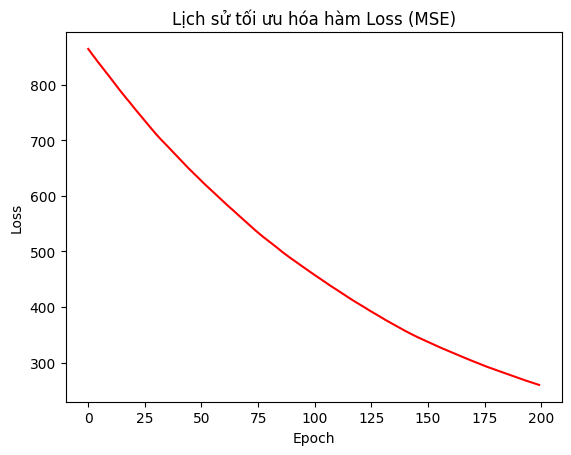

In [33]:
# Huấn luyện qua 200 epochs để đường thẳng khớp dần với dữ liệu
history = model.fit(X_train, y_train, epochs=200, verbose=0)

# Vẽ biểu đồ xem hàm Loss giảm dần theo thời gian
plt.plot(history.history['loss'], color='red')
plt.title('Lịch sử tối ưu hóa hàm Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


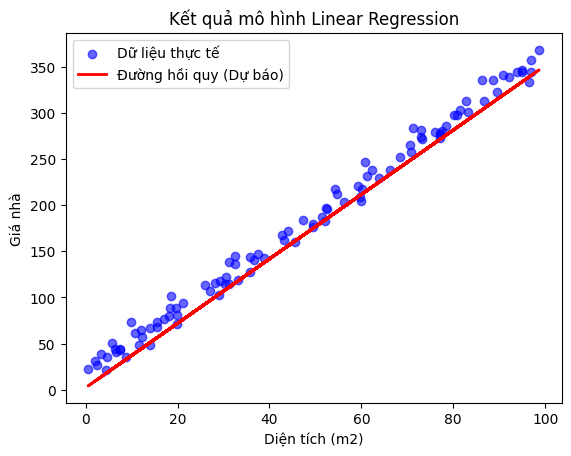

In [34]:
# Cho mô hình dự báo trên chính tập X_train để lấy ra đường thẳng regression
y_predict = model.predict(X_train)

# Vẽ đồ thị so sánh
plt.scatter(X_train, y_train, color='blue', label='Dữ liệu thực tế', alpha=0.6)
plt.plot(X_train, y_predict, color='red', linewidth=2, label='Đường hồi quy (Dự báo)')
plt.title('Kết quả mô hình Linear Regression')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá nhà')
plt.legend()
plt.show()